In [42]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

# Importing Libraries

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)

# Loading Dataset

In [44]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "breast_cancer.parquet")

print("Dataset loaded.")
print("Shape:", df.shape)

Dataset loaded.
Shape: (151, 54676)


# Dataset Inspection

In [45]:
df.head()

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552258_at,1552261_at,1552263_at,1552264_a_at,1552266_at,1552269_at,1552271_at,1552272_a_at,1552274_at,1552275_s_at,1552276_a_at,1552277_a_at,1552278_a_at,1552279_a_at,1552280_at,1552281_at,1552283_s_at,1552286_at,1552287_s_at,1552288_at,1552289_a_at,1552291_at,1552293_at,1552295_a_at,1552296_at,1552299_at,1552301_a_at,1552302_at,1552303_a_at,1552304_at,1552306_at,1552307_a_at,1552309_a_at,1552310_at,...,AFFX-HSAC07/X00351_3_at,AFFX-HSAC07/X00351_5_at,AFFX-HSAC07/X00351_M_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-HUMGAPDH/M33197_5_at,AFFX-HUMGAPDH/M33197_M_at,AFFX-HUMISGF3A/M97935_3_at,AFFX-HUMISGF3A/M97935_5_at,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-LysX-3_at,AFFX-LysX-5_at,AFFX-LysX-M_at,AFFX-M27830_3_at,AFFX-M27830_5_at,AFFX-M27830_M_at,AFFX-PheX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-r2-Bs-dap-3_at,AFFX-r2-Bs-dap-5_at,AFFX-r2-Bs-dap-M_at,AFFX-r2-Bs-lys-3_at,AFFX-r2-Bs-lys-5_at,AFFX-r2-Bs-lys-M_at,AFFX-r2-Bs-phe-3_at,AFFX-r2-Bs-phe-5_at,AFFX-r2-Bs-phe-M_at,AFFX-r2-Bs-thr-3_s_at,AFFX-r2-Bs-thr-5_s_at,AFFX-r2-Bs-thr-M_s_at,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Ec-bioB-5_at,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,3.278896,7.317273,6.941792,4.753893,9.689422,9.529577,4.416768,4.061347,6.468291,8.671009,3.766666,3.711459,5.076329,4.442042,6.741298,5.627442,5.516712,8.107137,4.956239,5.791278,3.569233,5.687476,4.152096,4.906925,8.206707,4.463950,5.186044,5.942088,4.191142,7.413500,3.281950,4.346253,3.883254,5.143185,5.953880,3.809546,4.903795,6.163062,5.960296,6.503104,...,13.617425,13.334688,13.611892,14.617621,13.620367,13.816580,13.953181,10.944267,8.018416,9.566412,9.015007,12.050521,14.750905,13.359472,5.576968,3.606041,4.481027,5.509117,10.544533,11.200692,5.932332,4.253946,5.052680,7.782348,7.056759,7.787824,4.784976,3.943038,3.903069,6.119248,4.461984,4.752744,6.761262,5.298281,6.048960,8.292124,8.225292,8.333854,9.854639,9.823276,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,basal,9.861358,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,3.589636,8.768128,7.567034,4.859823,8.459353,8.973671,4.503730,5.390424,6.756707,8.105795,4.651541,3.935309,5.228763,4.454780,6.468014,5.798596,5.306064,7.505800,4.636866,5.898319,3.749061,5.582313,4.449042,5.871074,7.242601,3.938327,4.378953,6.294126,4.058221,6.799876,3.004077,5.170231,3.915350,5.618675,6.103758,3.468310,3.805643,5.059153,7.665774,6.230720,...,13.724468,13.150683,13.449886,14.718935,13.650388,13.720148,13.877806,11.397179,8.665182,10.400596,9.371175,8.264719,9.938356,9.507651,6.103961,3.983088,4.742306,5.424171,8.881772,11.148811,6.330691,4.755615,5.474167,8.542725,7.617779,8.237535,5.209694,3.939264,4.553344,6.017351,5.425393,4.957181,7.405313,5.615380,6.617585,8.225366,8.409790,8.499343,10.061910,9.796947,12.178531,11.809408,13.750086,13.470146,6.771852,5.291005,5.405838,2.934763,3.687666,3.064299
2,basal,10.103478,8.936137,5.735970,7.687822,3.125932,6.562369,4.813449,4.425195,9.417956,3.552253,7.945086,7.238284,4.872635,9.367521,9.133688,4.358608,4.445164,5.476936,8.752114,3.546838,4.263868,5.509159,4.624205,7.103216,6.641263,5.141131,7.072525,4.728196,6.233648,3.766725,6.008163,4.191391,5.717077,7.809222,4.108028,5.012451,7.258626,4.330997,6.901454,4.032173,4.203554,4.133018,4.262457,4.463875,3.533392,4.019280,5.058569,5.264810,5.795663,...,13.484744,13.095263,13.307587,14.560461,14.012596,14.186929,14.372375,10.853230,8.196331,9.569713,8.842430,10.241912,13.605902,11.784268,5.8530

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Columns: 54676 entries, type to AFFX-TrpnX-M_at
dtypes: float32(54675), object(1)
memory usage: 31.5+ MB


## Identifying Target Column

In [47]:
target_col = "type"

## Identifying Class Distribution

In [48]:
class_counts = df[target_col].value_counts()

print(class_counts)

type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


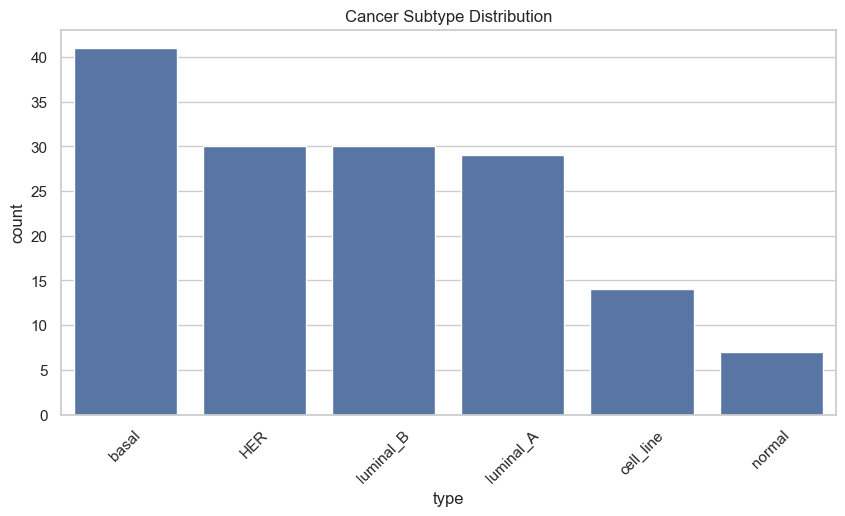

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x=target_col,
    order=class_counts.index
)

plt.title("Cancer Subtype Distribution")
plt.xticks(rotation=45)
plt.show()

## Missing Values

In [50]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## Separating Features & labels

In [51]:
X = df.drop(columns=[target_col])

y = df[target_col]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (151, 54675)
Labels shape: (151,)


## Gene Statistics

In [11]:
X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
samples,151.0,160.668874,45.431226,84.000000,121.500000,159.000000,200.500000,238.000000
1007_s_at,151.0,10.338902,0.613445,7.505488,10.103030,10.416820,10.735117,11.675109
1053_at,151.0,7.631910,0.706464,5.855968,7.166075,7.531673,8.053832,9.627008
117_at,151.0,6.224885,0.645435,4.763602,5.798087,6.235074,6.612292,8.364749
121_at,151.0,7.339249,0.330827,6.632206,7.105841,7.333426,7.513084,8.374055


### Gene Expression Distribution

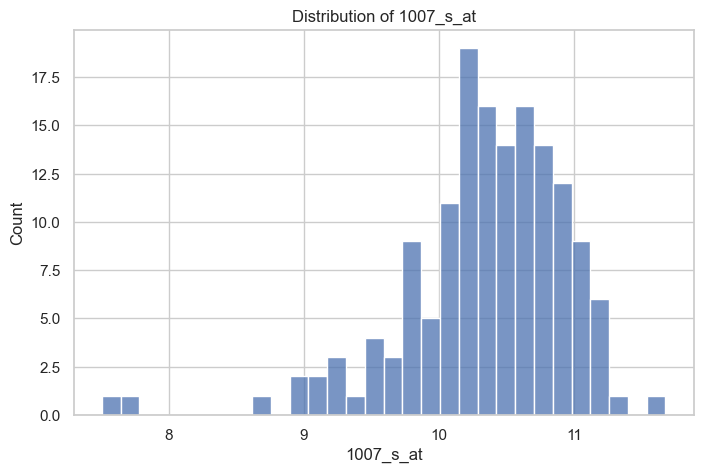

In [59]:
gene_1007_s_at = X.columns[0]

plt.figure(figsize=(8,5))

sns.histplot(X[gene_1007_s_at], bins=30)

plt.title(f"Distribution of {gene_1007_s_at}")
plt.show()

### Variance Analysis

In [39]:
gene_variances = X.drop('samples', axis = 'columns').var().sort_values(ascending=False)

gene_variances.head()

206378_at     17.083996
228241_at     13.367386
205916_at     11.137314
237339_at     10.873481
1553602_at    10.690824
dtype: float32

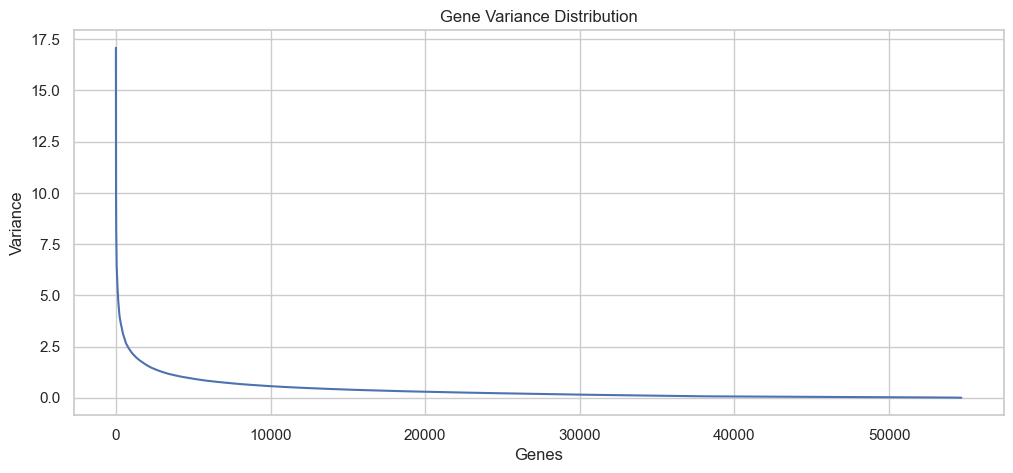

In [60]:
plt.figure(figsize=(12,5))

plt.plot(gene_variances.values)

plt.title("Gene Variance Distribution")
plt.xlabel("Genes")
plt.ylabel("Variance")

plt.show()

### Correlation Exploration

In [61]:
sample_genes = X.columns[:100]

corr_matrix = X[sample_genes].corr()

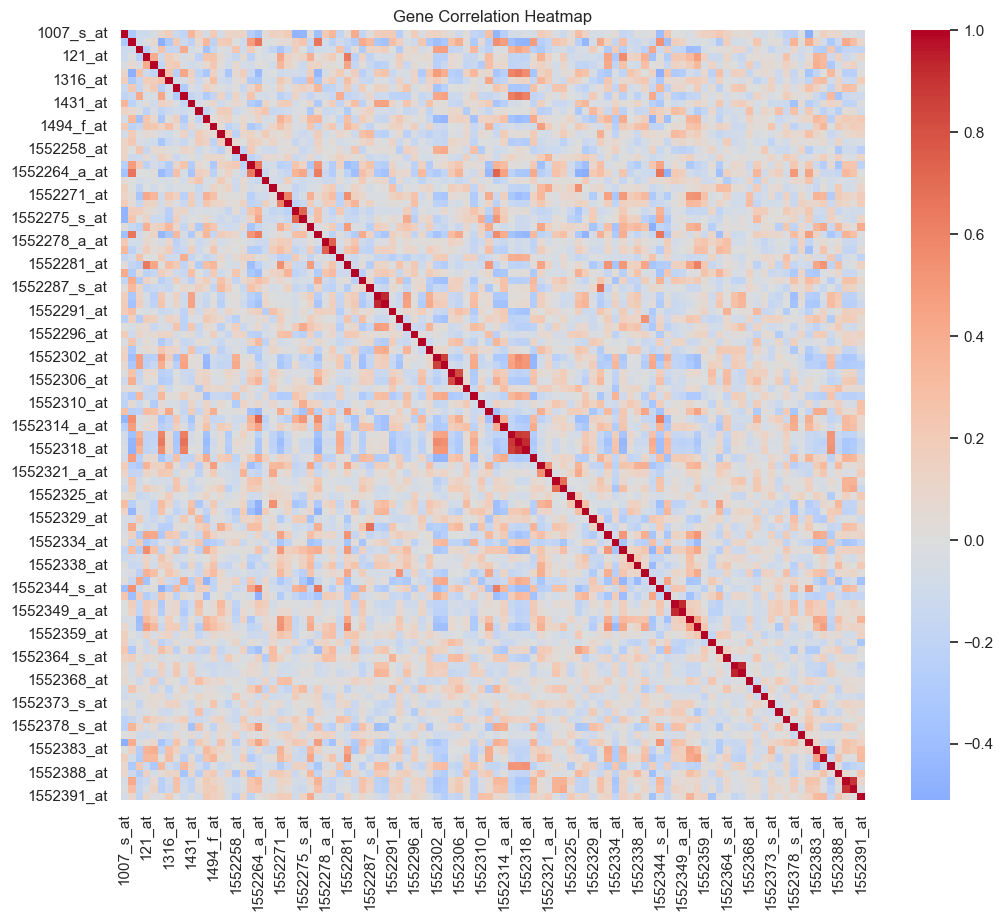

In [62]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Gene Correlation Heatmap")

plt.show()

## Scaling Before PCA

In [95]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

## PCA

In [96]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [97]:
print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.10061295 0.09313164]


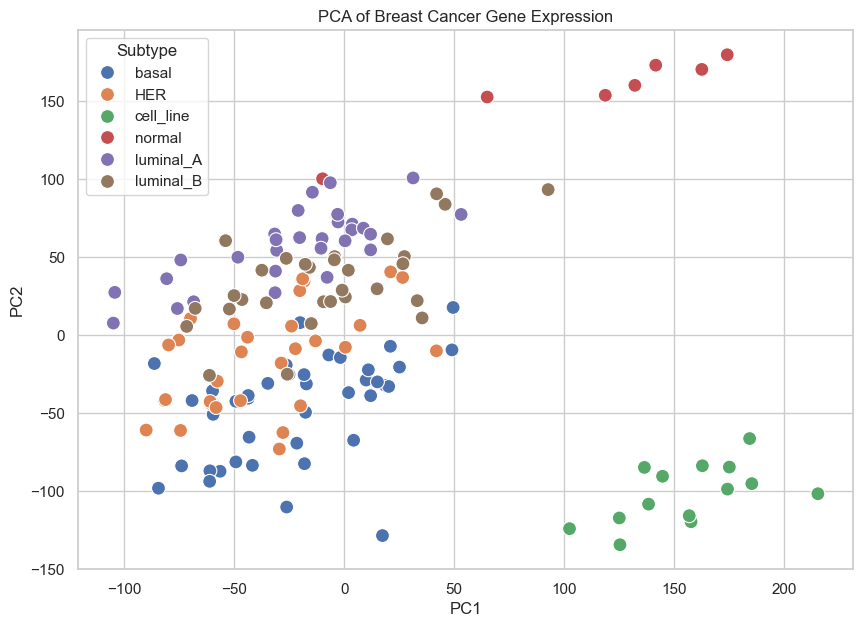

In [98]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Subtype": y
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Subtype",
    s=100
)

plt.title("PCA of Breast Cancer Gene Expression")

plt.show()

# Saving Artifacts

In [99]:
import joblib
joblib.dump(
    scaler,
    ARTIFACT_DIR / "Robust_scaler.pkl"
)

['C:\\Jupyter Notebook\\PROJECTS\\Breast_cancer_analysis\\data\\artifacts\\Robust_scaler.pkl']

In [101]:
pca_df.to_parquet(
    PROCESSED_DATA_DIR / "pca_2d.parquet",
    index=False
)
print("Done")

Done
